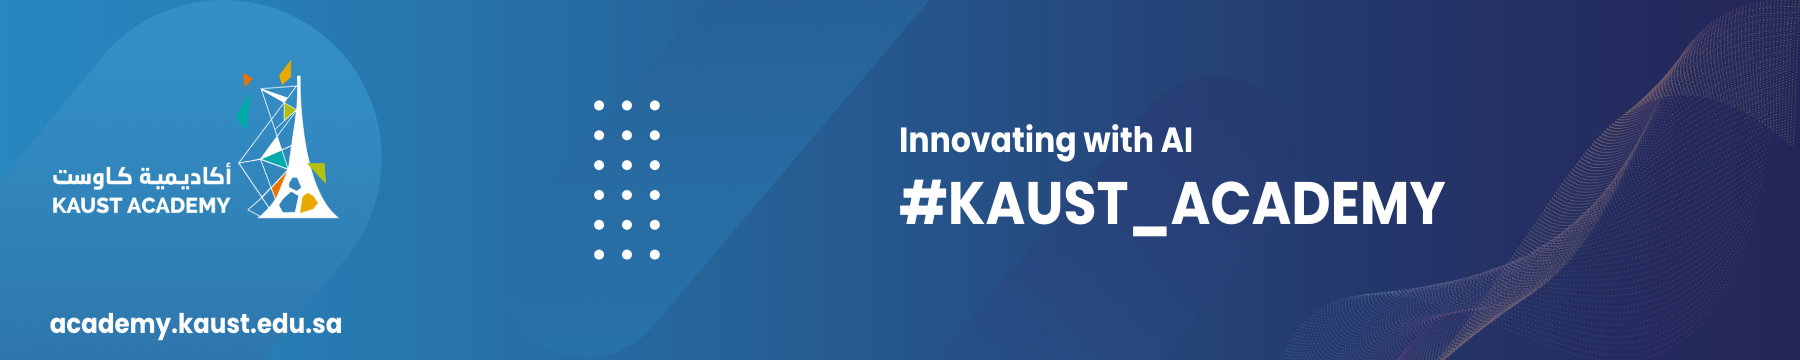

# Lab 3: Learning a Policy with REINFORCE


Value-based methods learn $Q(s,a)$ and derive the policy indirectly by choosing the action with the highest value:

$$
a = \arg\max_a Q(s,a)
$$

This approach can become difficult when:

- The action space is large or continuous.
- Evaluating every possible action is impractical.
- The optimal behavior should be stochastic.
- Learning the action strategy directly is easier than learning an accurate value for every action.

Policy-based methods instead learn:

$$
\pi_\theta(a \mid s)
$$

which directly maps a state to a probability distribution over actions.

### 1. Policy Gradient 

Instead of learning $Q(s,a)$ and choosing the best action indirectly, Policy Gradient methods learn a parameterized policy directly:

$$
\pi_\theta(a \mid s)
$$

The policy receives the current state and outputs a probability distribution over possible actions.



## Policy Network

```mermaid
flowchart LR
    A["Current State<br/>s_t"]

    B["Policy Network<br/>πθ(a | s_t)"]

    C["Action Probabilities<br/>[πθ(a₁|s_t), πθ(a₂|s_t), ..., πθ(aₙ|s_t)]"]

    D["Sample an Action<br/>a_t ~ πθ(. | s_t)"]

    E["Selected Action<br/>a_t"]

    A --> B --> C --> D --> E

In [1]:
!pip install "gymnasium[other]"


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import gymnasium as gym
import numpy as np

# Create the environment
env = gym.make("CartPole-v1")
base_env = env.unwrapped

# Names of the four state features
state_names = [
    "Cart position",
    "Cart velocity",
    "Pole angle",
    "Pole angular velocity",
]

print("=== CartPole-v1 Environment ===")

# General information
print(f"\nEnvironment: {env.spec.id}")
print(f"Observation space: {env.observation_space}")
print(f"Action space: {env.action_space}")
print(f"Maximum episode steps: {env.spec.max_episode_steps}")

# State information
print("\nState features:")
for index, name in enumerate(state_names):
    low = env.observation_space.low[index]
    high = env.observation_space.high[index]

    print(f"{index}: {name}")
    print(f"   Observation range: [{low}, {high}]")

# Action information
print("\nActions:")
print("0 = Push cart left")
print("1 = Push cart right")

# Termination conditions
print("\nTermination rules:")
print(
    f"- Cart position exceeds ±{base_env.x_threshold}"
)
print(
    "- Pole angle exceeds "
    f"±{np.degrees(base_env.theta_threshold_radians):.1f} degrees"
)
print(
    f"- Episode reaches {env.spec.max_episode_steps} timesteps"
)

# Reward rule
print("\nReward rule:")
print("- Reward = +1 for every timestep")
print("- Total episode reward equals the number of timesteps survived")

env.close()

=== CartPole-v1 Environment ===

Environment: CartPole-v1
Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)
Maximum episode steps: 500

State features:
0: Cart position
   Observation range: [-4.800000190734863, 4.800000190734863]
1: Cart velocity
   Observation range: [-inf, inf]
2: Pole angle
   Observation range: [-0.41887903213500977, 0.41887903213500977]
3: Pole angular velocity
   Observation range: [-inf, inf]

Actions:
0 = Push cart left
1 = Push cart right

Termination rules:
- Cart position exceeds ±2.4
- Pole angle exceeds ±12.0 degrees
- Episode reaches 500 timesteps

Reward rule:
- Reward = +1 for every timestep
- Total episode reward equals the number of timesteps survived


In [ ]:
import gymnasium as gym
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

env = gym.make(
    "CartPole-v1",
    render_mode="rgb_array"
)

state, info = env.reset(seed=42)

frames = []
terminated = False
truncated = False

while not terminated and not truncated:
    frames.append(env.render())

    # Random action: 0 = left, 1 = right
    action = env.action_space.sample()

    state, reward, terminated, truncated, info = env.step(action)

frames.append(env.render())
env.close()

fig, ax = plt.subplots(figsize=(8, 5))
image = ax.imshow(frames[0])
ax.axis("off")

def update(frame_number):
    image.set_data(frames[frame_number])
    ax.set_title(f"CartPole-v1 | Step {frame_number}")
    return [image]

animation = FuncAnimation(
    fig,
    update,
    frames=len(frames),
    interval=50
)

plt.close(fig)

HTML(animation.to_jshtml())

### Why CartPole Again?

-  On Day 2, CartPole was solved with **DQN**, a value-based method. Today, it is solved with **REINFORCE**, a policy-based method.

- **Fair comparison:** The environment stays unchanged:
  - 4-dimensional state
  - 2 discrete actions
  - Same reward system
  - Same episode limit and success criterion

- **Controlled experiment:** Because the task is identical, differences in performance are caused by the algorithm rather than the environment.

- **What to compare:**
  - Learning speed
  - Training stability
  - Variance across episodes
  - Sample efficiency
  - Final performance

- **Expected trade-off:**
  - DQN is usually more sample-efficient and lower-variance.
  - REINFORCE learns the policy directly and naturally supports stochastic policies.

### 2. Reinforce




```mermaid
flowchart TD
    A([Start]) --> B[Initialize policy model πθ]

    B --> C[Reset environment]
    C --> D[Generate one complete episode using πθ]

    D --> E[Store states St, actions At, rewards rt, and log-probabilities]

    E --> F[For t = T − 1 down to 0]

    F --> G["Compute discounted return<br/>Gt = Σ γ^(k−t) rk"]

    G --> H["Compute objective<br/>L(θ) = 1/T Σ Gt log πθ(At | St)"]

    H --> I["Compute training loss<br/>Loss = −L(θ)"]

    I --> J[Update policy parameters θ]

    J --> K{More episodes?}

    K -- Yes --> C
    K -- No --> L([End])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import torch.nn.functional as F
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

### 2.1 Policy Network

The policy network represents the agent’s policy:

$$
\pi_\theta(a \mid s)
$$

It receives the current state $s$ and outputs one score, called a **logit**, for each possible action.

In [ ]:
class Policy(nn.Module):
    def __init__(self, n_observations, n_actions):
        super().__init__()

        self.layer1 = nn.Linear(n_observations, 128)
        self.layer2 = nn.Linear(128, n_actions)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        return self.layer2(x)

    def act(self, state):
        state_tensor = torch.as_tensor(
            state,
            dtype=torch.float32,
            device=device
        ).unsqueeze(0)

        logits = self.forward(state_tensor)
         # TASK 1: sample an action and return it together with its log-probability.
        # HINT: build a Categorical distribution from `logits`, .sample() an action, and
        # use the distribution's .log_prob(action). Return (action.item(), log_prob).
        
        distribution = Categorical(logits=logits)
        
        action = distribution.sample()
        log_probability=distribution.log_prob(action)
        
    
        return action.item(), log_probability.squeeze()

### Hyperparameters

In [ ]:
# Hyperparameters
total_episodes = 600         
max_steps = 500              # Max steps per episode (CartPole-v1 truncates at 500)
learning_rate = 1e-3         
gamma = 0.99
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")     

### 2.2 Computing Discounted Returns

After completing one episode, REINFORCE calculates a return for every timestep.

For the action selected at timestep $t$, the discounted return is:

$$
G_t
=
r_t
+
\gamma r_{t+1}
+
\gamma^2 r_{t+2}
+\cdots
$$

Equivalently:

$$
G_t
=
\sum_{k=t}^{T-1}
\gamma^{k-t}r_k
$$

This is called the **causality trick** because an action is evaluated using only the reward received at that timestep and the rewards that occur after it.

The returns are calculated backwards:

$$
G_t = r_t + \gamma G_{t+1}
$$


In [ ]:
def compute_returns(rewards, gamma, device):
    """Compute the discounted return for every timestep."""

    returns = deque()
    running_return = 0.0
# TASK 2: Compute the discounted returns by iterating backward.
    #
    # Start from the final reward and move toward the first reward.
    # At each timestep, update the running return using:
    #
    #     G_t = r_t + gamma * G_{t+1}
    for reward in reversed(rewards):
        running_return = reward + gamma * running_return
        returns.appendleft(running_return)
    
    return torch.tensor(
        list(returns),
        dtype=torch.float32,
        device=device
    )

### 2.3 Initialize the Policy and Optimizer

In [8]:
state_size = env.observation_space.shape[0]
action_size = env.action_space.n
policy_net = Policy(state_size,action_size).to(device)

optimizer = optim.Adam(policy_net.parameters(),lr=learning_rate)
print("State size:", state_size)
print("Action size:", action_size)


State size: 4
Action size: 2


In [ ]:
def train_reinforce(env,policy_net,optimizer,total_episodes,max_steps,gamma,use_future_rewards=True,use_baseline=False):
    scores = []
    running_baseline = 0.0

    for episode in range(1, total_episodes + 1):

        state, _ = env.reset()

        saved_log_probs = []
        rewards = []

        for _ in range(max_steps):

            action, log_probability = policy_net.act(state)

            state, reward, terminated, truncated, _ = env.step(action)

            saved_log_probs.append(log_probability)
            rewards.append(reward)

            if terminated or truncated:
                break

        scores.append(sum(rewards))

        policy_device = next(policy_net.parameters()).device

        if use_future_rewards:
            returns = compute_returns(
                rewards,
                gamma,
                policy_device
            )

        else:
            full_return = sum(
                gamma ** step * reward
                for step, reward in enumerate(rewards)
            )

            returns = torch.full(
                (len(rewards),),
                full_return,
                dtype=torch.float32,
                device=policy_device
            )

        if use_baseline:
            baseline_value = running_baseline

            running_baseline = (
                0.95 * running_baseline
                + 0.05 * returns.mean().item()
            )

            returns = returns - baseline_value

        log_probs = torch.stack(saved_log_probs)
# TASK 3: Build the REINFORCE loss.
#
# Multiply each action's log-probability by its corresponding return,
# sum across all timesteps, and negate the result.
#
# Why the minus sign?
# REINFORCE wants to maximize expected return, but PyTorch minimizes loss.
#
# Formula:
#   loss = -Σ_t log π(a_t | s_t) G_t
        policy_loss = -(log_probs* returns).sum()
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

    return policy_net, scores

### 2.5 Run the Training


In [ ]:

trained_policy, scores = train_reinforce(
    env=env,
    policy_net=policy_net,
    optimizer=optimizer,
    total_episodes=total_episodes,
    max_steps=max_steps,
    gamma=gamma
)

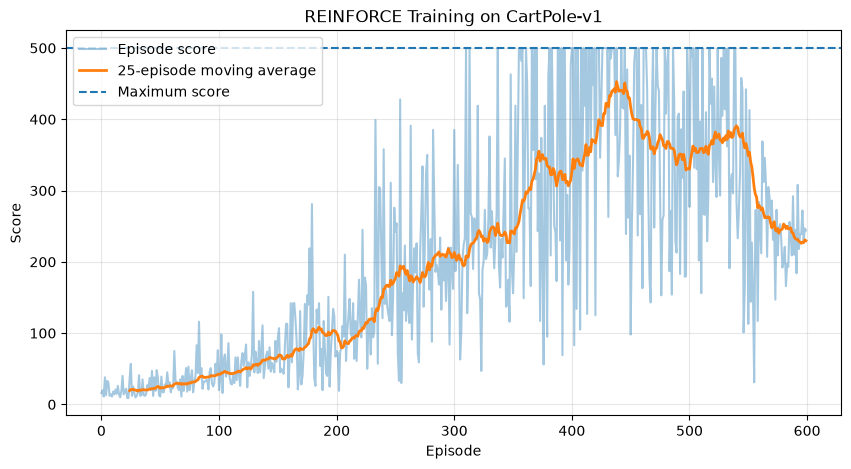

In [ ]:
def moving_average(values, window=25):
    values = np.asarray(values, dtype=float)

    if len(values) < window:
        return values

    weights = np.ones(window) / window
    return np.convolve(values, weights, mode="valid")
window=25
smoothed_scores = moving_average(scores, window)

plt.figure(figsize=(10, 5))

plt.plot(scores,alpha=0.4,label="Episode score")

plt.plot(
range(window - 1, len(scores)),
    smoothed_scores,
    linewidth=2,
    label=f"{window}-episode moving average"
)

plt.axhline(
    y=500,
    linestyle="--",
    label="Maximum score"
)

plt.xlabel("Episode")
plt.ylabel("Score")
plt.title("REINFORCE Training on CartPole-v1")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [14]:
import gymnasium as gym
import torch
import imageio
from pathlib import Path


def record_trained_agent(
    policy_net,
    name="reinforce_cartpole",
    max_steps=500,
    fps=30
):
    # Create CartPole with image rendering enabled
    env = gym.make(
        "CartPole-v1",
        render_mode="rgb_array"
    )

    state, _ = env.reset()

    frames = []
    total_reward = 0.0

    # Use the same device as the policy network
    policy_device = next(policy_net.parameters()).device

    # Evaluation mode
    policy_net.eval()

    for _ in range(max_steps):

        # Save the current frame
        frame = env.render()
        frames.append(frame)

        # Convert the current state to shape [1, 4]
        state_tensor = torch.as_tensor(
            state,
            dtype=torch.float32,
            device=policy_device
        ).unsqueeze(0)

        # Choose the action with the highest logit
        with torch.no_grad():
            logits = policy_net(state_tensor)
            action = torch.argmax(
                logits,
                dim=-1
            ).item()

        # Apply the action
        state, reward, terminated, truncated, _ = env.step(action)

        total_reward += reward

        if terminated or truncated:
            break

    env.close()

    # Create the GIF filename
    gif_path = Path(f"{name}.gif")

    # Save all frames as a GIF
    imageio.mimsave(
        str(gif_path),
        frames,
        fps=fps
    )

    print(f"Total reward: {total_reward}")
    print(f"GIF saved to: {gif_path.resolve()}")

    return str(gif_path)

Total reward: 219.0
GIF saved to: /home/lama/Downloads/reinforce_cartpole.gif


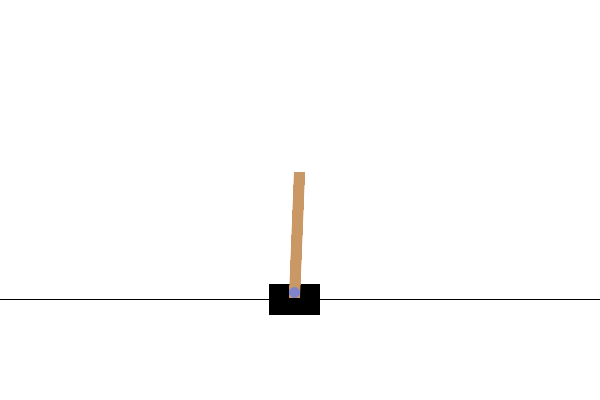

In [16]:
from IPython.display import Image, display
from pathlib import Path


gif_path = record_trained_agent(
    policy_net,
    name="reinforce_cartpole",
    max_steps=500,
    fps=30
)

if Path(gif_path).exists():
    display(
        Image(
            filename=gif_path
        )
    )
else:
    print(f"GIF file was not found: {Path(gif_path).resolve()}")

## 3. Variance Reduction: The Causality Trick and Baselines

The basic policy-gradient estimator gives every action the same full trajectory return:

$$
\nabla_\theta \mathcal{J}(\theta)
\approx
\sum_t
r(\tau)
\nabla_\theta
\log \pi_\theta(a_t \mid s_t)
$$

Although this estimator is unbiased, it can have very high variance because an action may be influenced by rewards that occurred before the action was selected.

Two common techniques can reduce this variance.

### 3.1 The Causality Trick

Each action is evaluated using only the reward received at that timestep and the rewards that follow it:

$$
G_t
=
\sum_{k=t}^{T-1}
\gamma^{k-t}r_k
$$

This prevents earlier rewards from being assigned to later actions.

### 3.2 Baseline

A baseline $b$ is subtracted from the return:

$$
A_t = G_t-b
$$

The resulting value is called the **advantage**.

- $A_t>0$: the action performed better than expected.
- $A_t<0$: the action performed worse than expected.

The REINFORCE loss with a baseline becomes:

$$
\text{Loss}
=
-\sum_t
\log \pi_\theta(a_t\mid s_t)
\left(G_t-b\right)
$$

The baseline reduces variance without changing the optimal policy.

### 3.3 Comparing Three Configurations

We will compare the following versions:

1. **Full trajectory return:** every action receives the same complete episode return.
2. **Causality trick:** every action receives only its discounted future return.
3. **Causality trick with baseline:** discounted future returns are adjusted using a baseline.

The three configurations should be trained with the same random seed and hyperparameters so that their learning curves can be compared fairly.

In [ ]:
configs = {
    "full trajectory return": {
        "use_future_rewards": False,
        "use_baseline": False
    },

    "causality trick (future rewards)": {
        "use_future_rewards": True,
        "use_baseline": False
    },

    "causality trick + baseline": {
        "use_future_rewards": True,
        "use_baseline": True
    },
}

In [ ]:
vr_scores = {}
vr_policies = {}

for name, cfg in configs.items():

    print(f"\n=== {name} ===")

    
    cmp_env = gym.make("CartPole-v1")

    state_size = cmp_env.observation_space.shape[0]
    action_size = cmp_env.action_space.n

    
    cmp_policy = Policy(state_size,action_size).to(device)

    
    cmp_optimizer = optim.Adam(
        cmp_policy.parameters(),
        lr=1e-3
    )

    trained_policy, sc = train_reinforce(
        env=cmp_env,
        policy_net=cmp_policy,
        optimizer=cmp_optimizer,
        total_episodes=400,
        max_steps=500,
        gamma=0.99,
        **cfg
    )

    vr_scores[name] = sc
    vr_policies[name] = trained_policy

    cmp_env.close()


=== full trajectory return ===

=== causality trick (future rewards) ===

=== causality trick + baseline ===


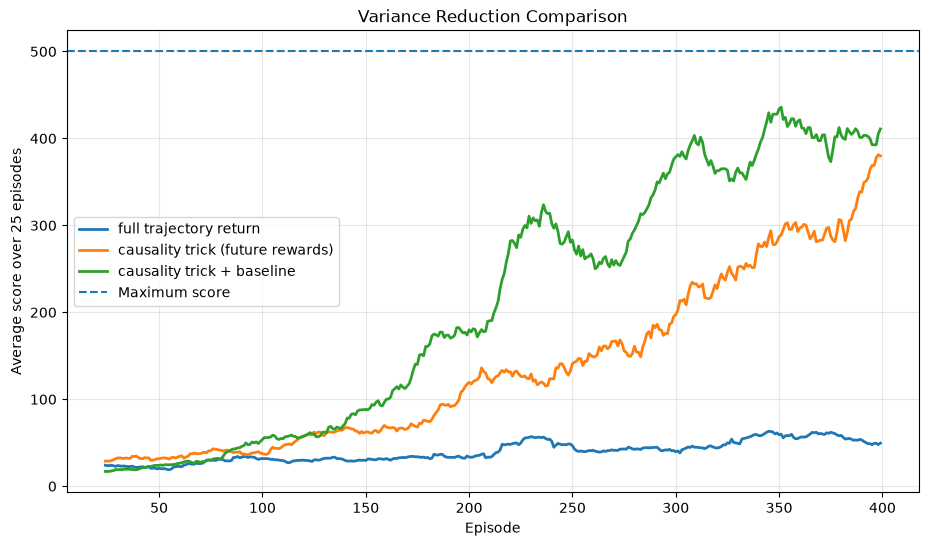

In [ ]:
window = 25

plt.figure(figsize=(11, 6))

for name, scores in vr_scores.items():
    smoothed = moving_average(scores, window)
    episodes = range(window - 1, window - 1 + len(smoothed))

    plt.plot(episodes,smoothed,linewidth=2,label=name)

plt.axhline(y=500,linestyle="--",label="Maximum score")

plt.xlabel("Episode")
plt.ylabel(f"Average score over {window} episodes")
plt.title("Variance Reduction Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**What to notice:**

- **Full trajectory return** learns slowly and erratically: every action in the episode is pushed by the *same* number, so the gradient is dominated by trajectory-level noise.
- **Causality trick** learns markedly faster — dropping the rewards an action could not have influenced removes noise without adding bias.
- **Causality trick + baseline** is faster and steadier still: subtracting the average return means good actions get a positive push and bad ones a negative push, instead of everything being nudged up just because all CartPole rewards are positive.

All three optimise the *same* objective — they differ only in the **variance** of the gradient estimate. This is why Day 4 goes further, replacing the moving-average baseline with a learned critic $V_\phi$ to estimate the advantage directly.